In [1]:
path = "D:\\TestJupyter\\data\\Stud_IT_2025_Module_3\\training_datasets"
path_train_data = path + '\\Train_data.pickle'
path_target_data = path + '\\Train_target.pickle'
path_test_data = path + '\\Test_data.pickle'

In [2]:
import pickle
import pandas as pd
import numpy as np

In [3]:
with open(path_train_data, 'rb') as open_train_data:
    raw_train_data = pickle.load(open_train_data)
with open(path_target_data, 'rb') as open_target_data:
    raw_target_data = pickle.load(open_target_data)
with open(path_test_data, 'rb') as open_test_data:
    raw_test_data = pickle.load(open_test_data)

In [4]:
raw_train_data

,positions,atomicNumbers,elements,charge,multiplicity,totalEnergy,gradient,dipoleMoment
id,,,,,,,,
289436,"[[2.7177422046661377, 0.1893724948167801, 1.18...","[3, 9, 15, 9, 9, 9, 9, 9]","[Li, F, P, F, F, F, F, F]",0.0,1.0,-948.513236,"[[0.023912517353892326, -0.0009200238273479044...","[[2.482706308364868], [0.08775771409273148], [..."
172291,"[[-2.809769630432129, 0.4285517930984497, -0.9...","[6, 6, 8, 6, 8, 6, 8, 1, 1, 1, 1, 1, 1, 6, 6, ...","[C, C, O, C, O, C, O, H, H, H, H, H, H, C, C, ...",0.0,1.0,-763.972140,"[[-0.034905705600976944, 0.02429979108273983, ...","[[0.865788459777832], [-0.3534996509552002], [..."
16145,"[[-0.6849300861358643, 1.1698198318481445, 0.7...","[6, 8, 6, 8, 6, 1, 1, 8, 1, 1]","[C, O, C, O, C, H, H, O, H, H]",0.0,1.0,-342.612273,"[[-0.02598184533417225, 0.0659920945763588, -0...","[[0.14613808691501617], [0.9436573386192322], ..."
12345,"[[4.158249855041504, 0.05714491382241249, -1.7...","[6, 8, 8, 8, 6, 6, 1, 1, 1, 1, 1, 1, 6, 8, 8, ...","[C, O, O, O, C, C, H, H, H, H, H, H, C, O, O, ...",0.0,1.0,-687.610542,"[[-0.1062416285276413, -0.05160133168101311, 0...","[[0.11332525312900543], [-0.21154789626598358]..."
45824,"[[-0.47792547941207886, 0.718813419342041, -1....","[6, 8, 6, 8, 6, 1, 1, 8, 1, 1]","[C, O, C, O, C, H, H, O, H, H]",0.0,1.0,-342.626351,"[[-0.01953810453414917, -0.0053415680304169655...","[[-0.7459930777549744], [0.6138357520103455], ..."
...,...,...,...,...,...,...,...,...
119879,"[[1.3755831718444824, 1.8097169399261475, -0.9...","[6, 8, 6, 8, 6, 1, 1, 8, 1, 1, 6, 8, 6, 8, 6, ...","[C, O, C, O, C, H, H, O, H, H, C, O, C, O, C, ...",0.0,1.0,-685.243087,"[[0.04350731149315834, 0.020168600603938103, 0...","[[-1.6112534999847412], [-0.4080508351325989],..."
259178,"[[-1.8912068605422974, -0.7673141956329346, -2...","[9, 15, 9, 9, 9, 9, 9, 6, 6, 8, 6, 8, 8, 9, 1,...","[F, P, F, F, F, F, F, C, C, O, C, O, O, F, H, ...",0.0,1.0,-1832.333954,"[[0.06576894223690033, 0.008227618411183357, 0...","[[2.740854024887085], [1.8966714143753052], [1..."
131932,"[[2.2375781536102295, 1.9658761024475098, -3.9...","[6, 8, 6, 8, 6, 1, 1, 8, 1, 1, 6, 8, 6, 8, 6, ...","[C, O, C, O, C, H, H, O, H, H, C, O, C, O, C, ...",0.0,1.0,-1027.839511,"[[-0.013407240621745586, 0.057573262602090836,...","[[1.6949660778045654], [-1.9628844261169434], ..."


In [5]:
raw_target_data

id
289436   -0.001268
172291   -0.169713
16145    -0.005004
12345     0.044586
45824    -0.019082
            ...   
119879   -0.028549
259178   -0.171488
131932   -0.017704
146867    0.008329
121958   -0.013714
Name: atomizationEnergy, Length: 271786, dtype: float64

In [6]:
raw_train_data.info()

<class 'pandas.DataFrame'>
Index: 271786 entries, 289436 to 121958
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   positions      269068 non-null  object 
 1   atomicNumbers  269068 non-null  object 
 2   elements       269068 non-null  object 
 3   charge         269080 non-null  float64
 4   multiplicity   269068 non-null  float64
 5   totalEnergy    269081 non-null  float64
 6   gradient       269068 non-null  object 
 7   dipoleMoment   269068 non-null  object 
dtypes: float64(3), object(5)
memory usage: 18.7+ MB


In [7]:
raw_target_data.info()

<class 'pandas.Series'>
Index: 271786 entries, 289436 to 121958
Series name: atomizationEnergy
Non-Null Count   Dtype  
--------------   -----  
271786 non-null  float64
dtypes: float64(1)
memory usage: 4.1 MB


In [8]:
nan_indexes = raw_train_data[raw_train_data.isna().any(axis = 1)].index.tolist()
nan_indexes

[72432,
 109070,
 355367,
 56778,
 113161,
 207144,
 78282,
 26947,
 334569,
 118132,
 77283,
 224349,
 121515,
 17245,
 85746,
 121662,
 98863,
 67506,
 261759,
 59399,
 33122,
 222150,
 307528,
 28862,
 280897,
 56292,
 299969,
 324204,
 11716,
 337467,
 3963,
 178182,
 336724,
 313210,
 99891,
 103662,
 127115,
 88321,
 272588,
 245414,
 67487,
 60006,
 270710,
 250594,
 25624,
 237233,
 2083,
 95638,
 224296,
 161594,
 198047,
 135199,
 255722,
 212732,
 115970,
 277704,
 104103,
 140293,
 333943,
 110890,
 131773,
 36612,
 222559,
 99474,
 131950,
 199256,
 167315,
 222634,
 210951,
 325105,
 241126,
 187249,
 320365,
 76513,
 117591,
 226347,
 177131,
 255000,
 47615,
 231717,
 327773,
 151335,
 96275,
 2044,
 89297,
 175676,
 189208,
 15985,
 342748,
 16809,
 14555,
 253008,
 110968,
 259890,
 198673,
 201233,
 52093,
 314090,
 178154,
 141291,
 53220,
 68632,
 100192,
 167559,
 105256,
 7619,
 272239,
 53538,
 39562,
 56450,
 31049,
 62337,
 41309,
 337554,
 109701,
 211658,
 2

In [9]:
dropped_train = raw_train_data.dropna().copy()

In [10]:
dropped_target = raw_target_data.drop(nan_indexes).copy()

In [11]:
dropped_target.info()

<class 'pandas.Series'>
Index: 269068 entries, 289436 to 121958
Series name: atomizationEnergy
Non-Null Count   Dtype  
--------------   -----  
269068 non-null  float64
dtypes: float64(1)
memory usage: 4.1 MB


In [12]:
dropped_train.info()

<class 'pandas.DataFrame'>
Index: 269068 entries, 289436 to 121958
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   positions      269068 non-null  object 
 1   atomicNumbers  269068 non-null  object 
 2   elements       269068 non-null  object 
 3   charge         269068 non-null  float64
 4   multiplicity   269068 non-null  float64
 5   totalEnergy    269068 non-null  float64
 6   gradient       269068 non-null  object 
 7   dipoleMoment   269068 non-null  object 
dtypes: float64(3), object(5)
memory usage: 18.5+ MB


In [13]:
ravel_df = dropped_train.copy()

In [14]:
ravel_df

,positions,atomicNumbers,elements,charge,multiplicity,totalEnergy,gradient,dipoleMoment
id,,,,,,,,
289436,"[[2.7177422046661377, 0.1893724948167801, 1.18...","[3, 9, 15, 9, 9, 9, 9, 9]","[Li, F, P, F, F, F, F, F]",0.0,1.0,-948.513236,"[[0.023912517353892326, -0.0009200238273479044...","[[2.482706308364868], [0.08775771409273148], [..."
172291,"[[-2.809769630432129, 0.4285517930984497, -0.9...","[6, 6, 8, 6, 8, 6, 8, 1, 1, 1, 1, 1, 1, 6, 6, ...","[C, C, O, C, O, C, O, H, H, H, H, H, H, C, C, ...",0.0,1.0,-763.972140,"[[-0.034905705600976944, 0.02429979108273983, ...","[[0.865788459777832], [-0.3534996509552002], [..."
16145,"[[-0.6849300861358643, 1.1698198318481445, 0.7...","[6, 8, 6, 8, 6, 1, 1, 8, 1, 1]","[C, O, C, O, C, H, H, O, H, H]",0.0,1.0,-342.612273,"[[-0.02598184533417225, 0.0659920945763588, -0...","[[0.14613808691501617], [0.9436573386192322], ..."
12345,"[[4.158249855041504, 0.05714491382241249, -1.7...","[6, 8, 8, 8, 6, 6, 1, 1, 1, 1, 1, 1, 6, 8, 8, ...","[C, O, O, O, C, C, H, H, H, H, H, H, C, O, O, ...",0.0,1.0,-687.610542,"[[-0.1062416285276413, -0.05160133168101311, 0...","[[0.11332525312900543], [-0.21154789626598358]..."
45824,"[[-0.47792547941207886, 0.718813419342041, -1....","[6, 8, 6, 8, 6, 1, 1, 8, 1, 1]","[C, O, C, O, C, H, H, O, H, H]",0.0,1.0,-342.626351,"[[-0.01953810453414917, -0.0053415680304169655...","[[-0.7459930777549744], [0.6138357520103455], ..."
...,...,...,...,...,...,...,...,...
119879,"[[1.3755831718444824, 1.8097169399261475, -0.9...","[6, 8, 6, 8, 6, 1, 1, 8, 1, 1, 6, 8, 6, 8, 6, ...","[C, O, C, O, C, H, H, O, H, H, C, O, C, O, C, ...",0.0,1.0,-685.243087,"[[0.04350731149315834, 0.020168600603938103, 0...","[[-1.6112534999847412], [-0.4080508351325989],..."
259178,"[[-1.8912068605422974, -0.7673141956329346, -2...","[9, 15, 9, 9, 9, 9, 9, 6, 6, 8, 6, 8, 8, 9, 1,...","[F, P, F, F, F, F, F, C, C, O, C, O, O, F, H, ...",0.0,1.0,-1832.333954,"[[0.06576894223690033, 0.008227618411183357, 0...","[[2.740854024887085], [1.8966714143753052], [1..."
131932,"[[2.2375781536102295, 1.9658761024475098, -3.9...","[6, 8, 6, 8, 6, 1, 1, 8, 1, 1, 6, 8, 6, 8, 6, ...","[C, O, C, O, C, H, H, O, H, H, C, O, C, O, C, ...",0.0,1.0,-1027.839511,"[[-0.013407240621745586, 0.057573262602090836,...","[[1.6949660778045654], [-1.9628844261169434], ..."


In [15]:
ravel_df['positions'] = ravel_df['positions'].apply(lambda i: i.ravel())
ravel_df['gradient'] = ravel_df['gradient'].apply(lambda i: i.ravel())
ravel_df['dipoleMoment'] = ravel_df['dipoleMoment'].apply(lambda i: i.ravel())

In [16]:
drop_elements = ravel_df.drop(columns='elements')
drop_elements

,positions,atomicNumbers,charge,multiplicity,totalEnergy,gradient,dipoleMoment
id,,,,,,,
289436,"[2.7177422046661377, 0.1893724948167801, 1.184...","[3, 9, 15, 9, 9, 9, 9, 9]",0.0,1.0,-948.513236,"[0.023912517353892326, -0.0009200238273479044,...","[2.482706308364868, 0.08775771409273148, 0.955..."
172291,"[-2.809769630432129, 0.4285517930984497, -0.96...","[6, 6, 8, 6, 8, 6, 8, 1, 1, 1, 1, 1, 1, 6, 6, ...",0.0,1.0,-763.972140,"[-0.034905705600976944, 0.02429979108273983, 0...","[0.865788459777832, -0.3534996509552002, -0.90..."
16145,"[-0.6849300861358643, 1.1698198318481445, 0.74...","[6, 8, 6, 8, 6, 1, 1, 8, 1, 1]",0.0,1.0,-342.612273,"[-0.02598184533417225, 0.0659920945763588, -0....","[0.14613808691501617, 0.9436573386192322, 0.56..."
12345,"[4.158249855041504, 0.05714491382241249, -1.70...","[6, 8, 8, 8, 6, 6, 1, 1, 1, 1, 1, 1, 6, 8, 8, ...",0.0,1.0,-687.610542,"[-0.1062416285276413, -0.05160133168101311, 0....","[0.11332525312900543, -0.21154789626598358, 0...."
45824,"[-0.47792547941207886, 0.718813419342041, -1.2...","[6, 8, 6, 8, 6, 1, 1, 8, 1, 1]",0.0,1.0,-342.626351,"[-0.01953810453414917, -0.0053415680304169655,...","[-0.7459930777549744, 0.6138357520103455, -0.4..."
...,...,...,...,...,...,...,...
119879,"[1.3755831718444824, 1.8097169399261475, -0.90...","[6, 8, 6, 8, 6, 1, 1, 8, 1, 1, 6, 8, 6, 8, 6, ...",0.0,1.0,-685.243087,"[0.04350731149315834, 0.020168600603938103, 0....","[-1.6112534999847412, -0.4080508351325989, -0...."
259178,"[-1.8912068605422974, -0.7673141956329346, -2....","[9, 15, 9, 9, 9, 9, 9, 6, 6, 8, 6, 8, 8, 9, 1,...",0.0,1.0,-1832.333954,"[0.06576894223690033, 0.008227618411183357, 0....","[2.740854024887085, 1.8966714143753052, 1.7012..."
131932,"[2.2375781536102295, 1.9658761024475098, -3.92...","[6, 8, 6, 8, 6, 1, 1, 8, 1, 1, 6, 8, 6, 8, 6, ...",0.0,1.0,-1027.839511,"[-0.013407240621745586, 0.057573262602090836, ...","[1.6949660778045654, -1.9628844261169434, 0.48..."


In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

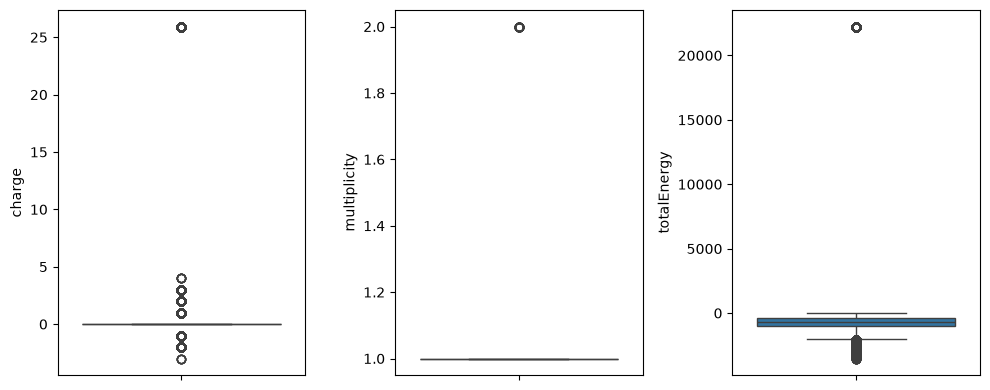

In [18]:
data = drop_elements.select_dtypes(include = 'number')
fig, axes = plt.subplots(1, data.shape[1], figsize = (10, 4))
for i, col in enumerate(data.columns):
    sns.boxplot(y=data[col], ax = axes[i])
plt.tight_layout()
plt.show()

In [19]:
mean_values = data.mean()
std_values = data.std()

# Расчет значения Z-score для каждого элемента
z_score = (data - mean_values) / std_values

# Фильтрация значений, находящихся за пределами ± 3 стандартных отклонений
filtered_df = data[(abs(z_score) < 2).all(axis = 1)]

filtered_df.describe()

,charge,multiplicity,totalEnergy
count,266336.000000,266336.0,266336.000000
mean,0.156888,1.0,-822.349395
std,0.609144,0.0,467.250809
min,-3.000000,1.0,-3529.440766
25%,0.000000,1.0,-1031.496408
50%,0.000000,1.0,-724.468102
75%,0.000000,1.0,-349.928427
max,4.000000,1.0,-1.162788


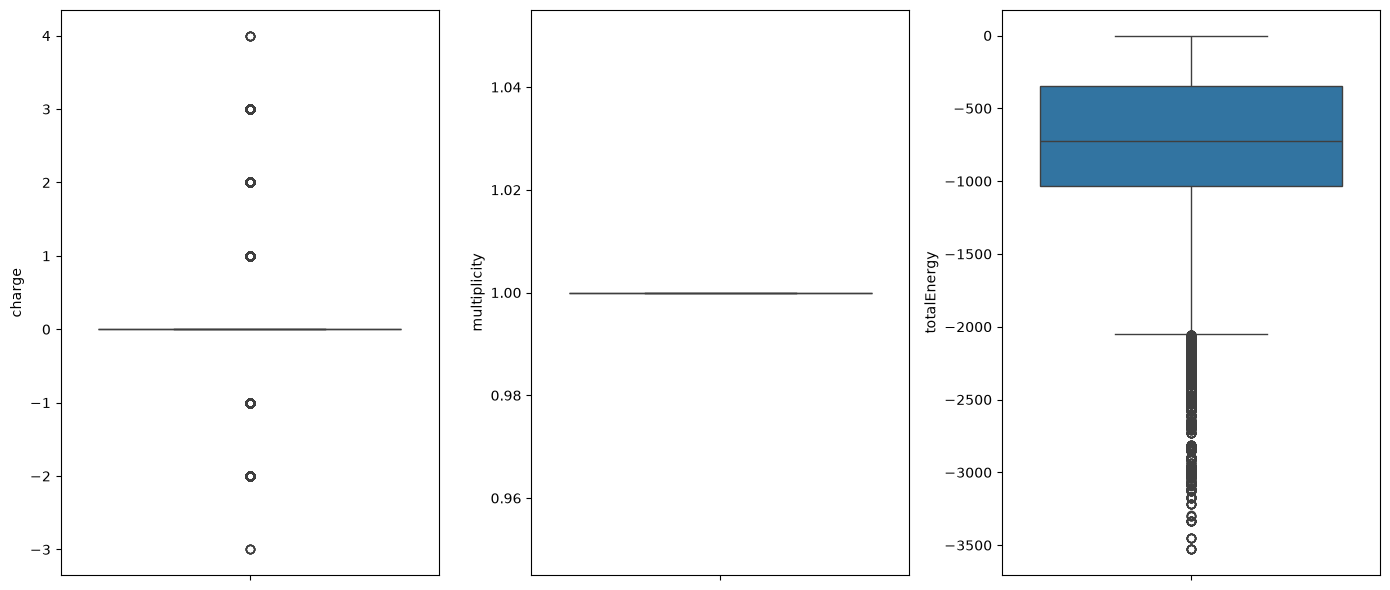

In [20]:
fig, axes = plt.subplots(1, data.shape[1], figsize = (14, 6))
for i, col in enumerate(data.columns):
    sns.boxplot(y=filtered_df[col], ax = axes[i])
plt.tight_layout()
plt.show()

In [21]:
out_df = data[(abs(z_score) > 2).any(axis = 1)]
data_out = drop_elements
data_out [(abs(z_score) >= 3)] = np.nan
data_filtered = data_out.ffill()
data_filtered = data_out.drop(labels=out_df.index, axis=0)
#Отфильтрованные данные

In [22]:
dropped2_target = dropped_target.drop(out_df.index)

In [23]:
dropped2_target

id
289436   -0.001268
172291   -0.169713
16145    -0.005004
12345     0.044586
45824    -0.019082
            ...   
119879   -0.028549
259178   -0.171488
131932   -0.017704
146867    0.008329
121958   -0.013714
Name: atomizationEnergy, Length: 266336, dtype: float64

In [24]:
data_filtered

,positions,atomicNumbers,charge,multiplicity,totalEnergy,gradient,dipoleMoment
id,,,,,,,
289436,"[2.7177422046661377, 0.1893724948167801, 1.184...","[3, 9, 15, 9, 9, 9, 9, 9]",0.0,1.0,-948.513236,"[0.023912517353892326, -0.0009200238273479044,...","[2.482706308364868, 0.08775771409273148, 0.955..."
172291,"[-2.809769630432129, 0.4285517930984497, -0.96...","[6, 6, 8, 6, 8, 6, 8, 1, 1, 1, 1, 1, 1, 6, 6, ...",0.0,1.0,-763.972140,"[-0.034905705600976944, 0.02429979108273983, 0...","[0.865788459777832, -0.3534996509552002, -0.90..."
16145,"[-0.6849300861358643, 1.1698198318481445, 0.74...","[6, 8, 6, 8, 6, 1, 1, 8, 1, 1]",0.0,1.0,-342.612273,"[-0.02598184533417225, 0.0659920945763588, -0....","[0.14613808691501617, 0.9436573386192322, 0.56..."
12345,"[4.158249855041504, 0.05714491382241249, -1.70...","[6, 8, 8, 8, 6, 6, 1, 1, 1, 1, 1, 1, 6, 8, 8, ...",0.0,1.0,-687.610542,"[-0.1062416285276413, -0.05160133168101311, 0....","[0.11332525312900543, -0.21154789626598358, 0...."
45824,"[-0.47792547941207886, 0.718813419342041, -1.2...","[6, 8, 6, 8, 6, 1, 1, 8, 1, 1]",0.0,1.0,-342.626351,"[-0.01953810453414917, -0.0053415680304169655,...","[-0.7459930777549744, 0.6138357520103455, -0.4..."
...,...,...,...,...,...,...,...
119879,"[1.3755831718444824, 1.8097169399261475, -0.90...","[6, 8, 6, 8, 6, 1, 1, 8, 1, 1, 6, 8, 6, 8, 6, ...",0.0,1.0,-685.243087,"[0.04350731149315834, 0.020168600603938103, 0....","[-1.6112534999847412, -0.4080508351325989, -0...."
259178,"[-1.8912068605422974, -0.7673141956329346, -2....","[9, 15, 9, 9, 9, 9, 9, 6, 6, 8, 6, 8, 8, 9, 1,...",0.0,1.0,-1832.333954,"[0.06576894223690033, 0.008227618411183357, 0....","[2.740854024887085, 1.8966714143753052, 1.7012..."
131932,"[2.2375781536102295, 1.9658761024475098, -3.92...","[6, 8, 6, 8, 6, 1, 1, 8, 1, 1, 6, 8, 6, 8, 6, ...",0.0,1.0,-1027.839511,"[-0.013407240621745586, 0.057573262602090836, ...","[1.6949660778045654, -1.9628844261169434, 0.48..."


In [25]:
df_lens = data_filtered.drop(columns=['charge', 'multiplicity', 'totalEnergy']).map(len)
df_lens

,positions,atomicNumbers,gradient,dipoleMoment
id,,,,
289436,24,8,24,3
172291,78,26,78,3
16145,30,10,30,3
12345,72,24,72,3
45824,30,10,30,3
...,...,...,...,...
119879,60,20,60,3
259178,84,28,84,3
131932,90,30,90,3


In [26]:
max_lengths = {}
for i in df_lens:
    max_lengths[i] = max(df_lens[i])
max_lengths

{'positions': 270, 'atomicNumbers': 90, 'gradient': 270, 'dipoleMoment': 3}

In [27]:
type(data_filtered['positions'].iloc[0])

numpy.ndarray

In [28]:
def add_zeros(value, column=0):
    if column in max_lengths:
        pad_size = max_lengths[column] - len(value)
        value = np.pad(value, (0, pad_size), mode='constant')
    return value

In [29]:
df_normalized = data_filtered.copy()
for i in df_normalized:
    df_normalized[i] = df_normalized[i].apply(lambda x: add_zeros(x, i))
df_normalized

,positions,atomicNumbers,charge,multiplicity,totalEnergy,gradient,dipoleMoment
id,,,,,,,
289436,"[2.7177422046661377, 0.1893724948167801, 1.184...","[3, 9, 15, 9, 9, 9, 9, 9, 0, 0, 0, 0, 0, 0, 0,...",0.0,1.0,-948.513236,"[0.023912517353892326, -0.0009200238273479044,...","[2.482706308364868, 0.08775771409273148, 0.955..."
172291,"[-2.809769630432129, 0.4285517930984497, -0.96...","[6, 6, 8, 6, 8, 6, 8, 1, 1, 1, 1, 1, 1, 6, 6, ...",0.0,1.0,-763.972140,"[-0.034905705600976944, 0.02429979108273983, 0...","[0.865788459777832, -0.3534996509552002, -0.90..."
16145,"[-0.6849300861358643, 1.1698198318481445, 0.74...","[6, 8, 6, 8, 6, 1, 1, 8, 1, 1, 0, 0, 0, 0, 0, ...",0.0,1.0,-342.612273,"[-0.02598184533417225, 0.0659920945763588, -0....","[0.14613808691501617, 0.9436573386192322, 0.56..."
12345,"[4.158249855041504, 0.05714491382241249, -1.70...","[6, 8, 8, 8, 6, 6, 1, 1, 1, 1, 1, 1, 6, 8, 8, ...",0.0,1.0,-687.610542,"[-0.1062416285276413, -0.05160133168101311, 0....","[0.11332525312900543, -0.21154789626598358, 0...."
45824,"[-0.47792547941207886, 0.718813419342041, -1.2...","[6, 8, 6, 8, 6, 1, 1, 8, 1, 1, 0, 0, 0, 0, 0, ...",0.0,1.0,-342.626351,"[-0.01953810453414917, -0.0053415680304169655,...","[-0.7459930777549744, 0.6138357520103455, -0.4..."
...,...,...,...,...,...,...,...
119879,"[1.3755831718444824, 1.8097169399261475, -0.90...","[6, 8, 6, 8, 6, 1, 1, 8, 1, 1, 6, 8, 6, 8, 6, ...",0.0,1.0,-685.243087,"[0.04350731149315834, 0.020168600603938103, 0....","[-1.6112534999847412, -0.4080508351325989, -0...."
259178,"[-1.8912068605422974, -0.7673141956329346, -2....","[9, 15, 9, 9, 9, 9, 9, 6, 6, 8, 6, 8, 8, 9, 1,...",0.0,1.0,-1832.333954,"[0.06576894223690033, 0.008227618411183357, 0....","[2.740854024887085, 1.8966714143753052, 1.7012..."
131932,"[2.2375781536102295, 1.9658761024475098, -3.92...","[6, 8, 6, 8, 6, 1, 1, 8, 1, 1, 6, 8, 6, 8, 6, ...",0.0,1.0,-1027.839511,"[-0.013407240621745586, 0.057573262602090836, ...","[1.6949660778045654, -1.9628844261169434, 0.48..."


In [30]:
df_normalized.iloc[0]

positions        [2.7177422046661377, 0.1893724948167801, 1.184...
atomicNumbers    [3, 9, 15, 9, 9, 9, 9, 9, 0, 0, 0, 0, 0, 0, 0,...
charge                                                         0.0
multiplicity                                                   1.0
totalEnergy                                            -948.513236
gradient         [0.023912517353892326, -0.0009200238273479044,...
dipoleMoment     [2.482706308364868, 0.08775771409273148, 0.955...
Name: 289436, dtype: object

In [31]:
flat_list = np.hstack(df_normalized.iloc[0].values).tolist()
df_normalized['flat_list'] = df_normalized.apply(lambda row: np.hstack(row.values).tolist(), axis=1)
df_normalized

,positions,atomicNumbers,charge,multiplicity,totalEnergy,gradient,dipoleMoment,flat_list
id,,,,,,,,
289436,"[2.7177422046661377, 0.1893724948167801, 1.184...","[3, 9, 15, 9, 9, 9, 9, 9, 0, 0, 0, 0, 0, 0, 0,...",0.0,1.0,-948.513236,"[0.023912517353892326, -0.0009200238273479044,...","[2.482706308364868, 0.08775771409273148, 0.955...","[2.7177422046661377, 0.1893724948167801, 1.184..."
172291,"[-2.809769630432129, 0.4285517930984497, -0.96...","[6, 6, 8, 6, 8, 6, 8, 1, 1, 1, 1, 1, 1, 6, 6, ...",0.0,1.0,-763.972140,"[-0.034905705600976944, 0.02429979108273983, 0...","[0.865788459777832, -0.3534996509552002, -0.90...","[-2.809769630432129, 0.4285517930984497, -0.96..."
16145,"[-0.6849300861358643, 1.1698198318481445, 0.74...","[6, 8, 6, 8, 6, 1, 1, 8, 1, 1, 0, 0, 0, 0, 0, ...",0.0,1.0,-342.612273,"[-0.02598184533417225, 0.0659920945763588, -0....","[0.14613808691501617, 0.9436573386192322, 0.56...","[-0.6849300861358643, 1.1698198318481445, 0.74..."
12345,"[4.158249855041504, 0.05714491382241249, -1.70...","[6, 8, 8, 8, 6, 6, 1, 1, 1, 1, 1, 1, 6, 8, 8, ...",0.0,1.0,-687.610542,"[-0.1062416285276413, -0.05160133168101311, 0....","[0.11332525312900543, -0.21154789626598358, 0....","[4.158249855041504, 0.05714491382241249, -1.70..."
45824,"[-0.47792547941207886, 0.718813419342041, -1.2...","[6, 8, 6, 8, 6, 1, 1, 8, 1, 1, 0, 0, 0, 0, 0, ...",0.0,1.0,-342.626351,"[-0.01953810453414917, -0.0053415680304169655,...","[-0.7459930777549744, 0.6138357520103455, -0.4...","[-0.47792547941207886, 0.718813419342041, -1.2..."
...,...,...,...,...,...,...,...,...
119879,"[1.3755831718444824, 1.8097169399261475, -0.90...","[6, 8, 6, 8, 6, 1, 1, 8, 1, 1, 6, 8, 6, 8, 6, ...",0.0,1.0,-685.243087,"[0.04350731149315834, 0.020168600603938103, 0....","[-1.6112534999847412, -0.4080508351325989, -0....","[1.3755831718444824, 1.8097169399261475, -0.90..."
259178,"[-1.8912068605422974, -0.7673141956329346, -2....","[9, 15, 9, 9, 9, 9, 9, 6, 6, 8, 6, 8, 8, 9, 1,...",0.0,1.0,-1832.333954,"[0.06576894223690033, 0.008227618411183357, 0....","[2.740854024887085, 1.8966714143753052, 1.7012...","[-1.8912068605422974, -0.7673141956329346, -2...."
131932,"[2.2375781536102295, 1.9658761024475098, -3.92...","[6, 8, 6, 8, 6, 1, 1, 8, 1, 1, 6, 8, 6, 8, 6, ...",0.0,1.0,-1027.839511,"[-0.013407240621745586, 0.057573262602090836, ...","[1.6949660778045654, -1.9628844261169434, 0.48...","[2.2375781536102295, 1.9658761024475098, -3.92..."


In [32]:
df_normalized['flat_list']

id
289436    [2.7177422046661377, 0.1893724948167801, 1.184...
172291    [-2.809769630432129, 0.4285517930984497, -0.96...
16145     [-0.6849300861358643, 1.1698198318481445, 0.74...
12345     [4.158249855041504, 0.05714491382241249, -1.70...
45824     [-0.47792547941207886, 0.718813419342041, -1.2...
                                ...                        
119879    [1.3755831718444824, 1.8097169399261475, -0.90...
259178    [-1.8912068605422974, -0.7673141956329346, -2....
131932    [2.2375781536102295, 1.9658761024475098, -3.92...
146867    [-0.861930251121521, 1.1034585237503052, -0.70...
121958    [0.08739743381738663, -0.4887195825576782, 1.4...
Name: flat_list, Length: 266336, dtype: object

In [33]:
X = np.stack(df_normalized['flat_list'])
y = dropped2_target


In [34]:
X

array([[ 2.7177422 ,  0.18937249,  1.18467343, ...,  2.48270631,
         0.08775771,  0.95504564],
       [-2.80976963,  0.42855179, -0.96908551, ...,  0.86578846,
        -0.35349965, -0.90517932],
       [-0.68493009,  1.16981983,  0.74941361, ...,  0.14613809,
         0.94365734,  0.56235003],
       ...,
       [ 2.23757815,  1.9658761 , -3.92955279, ...,  1.69496608,
        -1.96288443,  0.4804343 ],
       [-0.86193025,  1.10345852, -0.70635754, ..., -1.00440586,
         0.5029338 , -0.17664166],
       [ 0.08739743, -0.48871958,  1.49374986, ...,  0.55325747,
        -0.73781139,  0.8842532 ]])

In [35]:
from sklearn.model_selection import train_test_split

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [37]:
X_train

array([[-1.30650401, -2.35176706,  2.23307323, ...,  1.0304352 ,
        -1.10922015, -1.62453496],
       [ 2.9011972 , -1.728392  ,  2.83343911, ..., -0.24124838,
        -1.84736037, -1.82076728],
       [-0.23629397,  0.65386581,  1.43583286, ..., -0.70947683,
         0.22653034,  0.94110107],
       ...,
       [ 4.19065666, -2.19402242,  0.30052814, ...,  2.54544258,
        -1.96690702,  0.96202558],
       [-0.84898704, -1.08077228, -0.56484187, ..., -0.043215  ,
        -0.76715803, -0.6236825 ],
       [-1.12257695,  0.81436664, -0.73345774, ..., -0.54075545,
         0.32180768, -0.98142993]])

In [38]:
from sklearn.preprocessing import StandardScaler

In [39]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [40]:
from sklearn import linear_model

In [41]:
reg_model = linear_model.Ridge(alpha=.5)
reg_model.fit(X_train, y_train)


,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",0.5
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

In [42]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [43]:
prediction = reg_model.predict(X_test)

In [44]:
MSE = mean_squared_error(y_test, prediction)
r2 = r2_score(y_test, prediction)
MAE = mean_absolute_error(y_test, prediction)

In [45]:
MSE

0.04242221128264131

In [46]:
r2

0.3974166996756051

In [47]:
MAE

0.09181828505197097

1.3.1. Для каждой фичи, содержащей массивы, создайте новую фичу, отражающую длину данного массива;
1.3.2. Для фичи positions создайте новый столбец, содержащий максимальное декартово расстояние для атома от центра координат;
1.3.3. Для фичи positions создайте новый столбец, содержащий минимальное декартово расстояние для атома от центра координат;
1.3.4. Для фичи positions создайте новый столбец, содержащий среднее декартово расстояние между двумя атомами молекулы;
1.3.5. Для фичи atomicNumbers или elements подсчитайте кол-во входящих в молекулу атомов водорода, лития, углерода, кислорода, фтора, фосфора и добавьте в качестве отдельных столбцов;
1.3.6. Для столбца elements подсчитайте количество связей между кислородом и углеродом (CΞO | ОΞС). Количество таких связей добавьте в качестве нового столбца;
1.3.7. Для столбца elements подсчитайте количество связей между водородом и углеродом (CΞH | HΞС). Количество таких связей добавьте в качестве нового столбца;

In [48]:
data_filtered

,positions,atomicNumbers,charge,multiplicity,totalEnergy,gradient,dipoleMoment
id,,,,,,,
289436,"[2.7177422046661377, 0.1893724948167801, 1.184...","[3, 9, 15, 9, 9, 9, 9, 9]",0.0,1.0,-948.513236,"[0.023912517353892326, -0.0009200238273479044,...","[2.482706308364868, 0.08775771409273148, 0.955..."
172291,"[-2.809769630432129, 0.4285517930984497, -0.96...","[6, 6, 8, 6, 8, 6, 8, 1, 1, 1, 1, 1, 1, 6, 6, ...",0.0,1.0,-763.972140,"[-0.034905705600976944, 0.02429979108273983, 0...","[0.865788459777832, -0.3534996509552002, -0.90..."
16145,"[-0.6849300861358643, 1.1698198318481445, 0.74...","[6, 8, 6, 8, 6, 1, 1, 8, 1, 1]",0.0,1.0,-342.612273,"[-0.02598184533417225, 0.0659920945763588, -0....","[0.14613808691501617, 0.9436573386192322, 0.56..."
12345,"[4.158249855041504, 0.05714491382241249, -1.70...","[6, 8, 8, 8, 6, 6, 1, 1, 1, 1, 1, 1, 6, 8, 8, ...",0.0,1.0,-687.610542,"[-0.1062416285276413, -0.05160133168101311, 0....","[0.11332525312900543, -0.21154789626598358, 0...."
45824,"[-0.47792547941207886, 0.718813419342041, -1.2...","[6, 8, 6, 8, 6, 1, 1, 8, 1, 1]",0.0,1.0,-342.626351,"[-0.01953810453414917, -0.0053415680304169655,...","[-0.7459930777549744, 0.6138357520103455, -0.4..."
...,...,...,...,...,...,...,...
119879,"[1.3755831718444824, 1.8097169399261475, -0.90...","[6, 8, 6, 8, 6, 1, 1, 8, 1, 1, 6, 8, 6, 8, 6, ...",0.0,1.0,-685.243087,"[0.04350731149315834, 0.020168600603938103, 0....","[-1.6112534999847412, -0.4080508351325989, -0...."
259178,"[-1.8912068605422974, -0.7673141956329346, -2....","[9, 15, 9, 9, 9, 9, 9, 6, 6, 8, 6, 8, 8, 9, 1,...",0.0,1.0,-1832.333954,"[0.06576894223690033, 0.008227618411183357, 0....","[2.740854024887085, 1.8966714143753052, 1.7012..."
131932,"[2.2375781536102295, 1.9658761024475098, -3.92...","[6, 8, 6, 8, 6, 1, 1, 8, 1, 1, 6, 8, 6, 8, 6, ...",0.0,1.0,-1027.839511,"[-0.013407240621745586, 0.057573262602090836, ...","[1.6949660778045654, -1.9628844261169434, 0.48..."


In [49]:
data_len = data_filtered.copy()

In [50]:
data_len['len_positions'] = data_len['positions'].apply(len)
data_len['len_atomicNumbers'] = data_len['atomicNumbers'].apply(len)
data_len['len_gradient'] = data_len['gradient'].apply(len)
data_len['len_dipoleMoment'] = data_len['dipoleMoment'].apply(len)


In [51]:
data_len

,positions,atomicNumbers,charge,multiplicity,totalEnergy,gradient,dipoleMoment,len_positions,len_atomicNumbers,len_gradient,len_dipoleMoment
id,,,,,,,,,,,
289436,"[2.7177422046661377, 0.1893724948167801, 1.184...","[3, 9, 15, 9, 9, 9, 9, 9]",0.0,1.0,-948.513236,"[0.023912517353892326, -0.0009200238273479044,...","[2.482706308364868, 0.08775771409273148, 0.955...",24,8,24,3
172291,"[-2.809769630432129, 0.4285517930984497, -0.96...","[6, 6, 8, 6, 8, 6, 8, 1, 1, 1, 1, 1, 1, 6, 6, ...",0.0,1.0,-763.972140,"[-0.034905705600976944, 0.02429979108273983, 0...","[0.865788459777832, -0.3534996509552002, -0.90...",78,26,78,3
16145,"[-0.6849300861358643, 1.1698198318481445, 0.74...","[6, 8, 6, 8, 6, 1, 1, 8, 1, 1]",0.0,1.0,-342.612273,"[-0.02598184533417225, 0.0659920945763588, -0....","[0.14613808691501617, 0.9436573386192322, 0.56...",30,10,30,3
12345,"[4.158249855041504, 0.05714491382241249, -1.70...","[6, 8, 8, 8, 6, 6, 1, 1, 1, 1, 1, 1, 6, 8, 8, ...",0.0,1.0,-687.610542,"[-0.1062416285276413, -0.05160133168101311, 0....","[0.11332525312900543, -0.21154789626598358, 0....",72,24,72,3
45824,"[-0.47792547941207886, 0.718813419342041, -1.2...","[6, 8, 6, 8, 6, 1, 1, 8, 1, 1]",0.0,1.0,-342.626351,"[-0.01953810453414917, -0.0053415680304169655,...","[-0.7459930777549744, 0.6138357520103455, -0.4...",30,10,30,3
...,...,...,...,...,...,...,...,...,...,...,...
119879,"[1.3755831718444824, 1.8097169399261475, -0.90...","[6, 8, 6, 8, 6, 1, 1, 8, 1, 1, 6, 8, 6, 8, 6, ...",0.0,1.0,-685.243087,"[0.04350731149315834, 0.020168600603938103, 0....","[-1.6112534999847412, -0.4080508351325989, -0....",60,20,60,3
259178,"[-1.8912068605422974, -0.7673141956329346, -2....","[9, 15, 9, 9, 9, 9, 9, 6, 6, 8, 6, 8, 8, 9, 1,...",0.0,1.0,-1832.333954,"[0.06576894223690033, 0.008227618411183357, 0....","[2.740854024887085, 1.8966714143753052, 1.7012...",84,28,84,3
131932,"[2.2375781536102295, 1.9658761024475098, -3.92...","[6, 8, 6, 8, 6, 1, 1, 8, 1, 1, 6, 8, 6, 8, 6, ...",0.0,1.0,-1027.839511,"[-0.013407240621745586, 0.057573262602090836, ...","[1.6949660778045654, -1.9628844261169434, 0.48...",90,30,90,3


Функция для нормализации датафрейма для проверки каждой фичи

In [52]:
def normalazer (data):
    df_normalized = data.copy()
    for i in df_normalized:
        df_normalized[i] = df_normalized[i].apply(lambda x: add_zeros(x, i))
    
    flat_list = np.hstack(df_normalized.iloc[0].values).tolist()
    df_normalized['flat_list'] = df_normalized.apply(lambda row: np.hstack(row.values).tolist(), axis=1)
    return df_normalized

In [53]:
len_normalazed = normalazer(data_len).copy()
len_normalazed

,positions,atomicNumbers,charge,multiplicity,totalEnergy,gradient,dipoleMoment,len_positions,len_atomicNumbers,len_gradient,len_dipoleMoment,flat_list
id,,,,,,,,,,,,
289436,"[2.7177422046661377, 0.1893724948167801, 1.184...","[3, 9, 15, 9, 9, 9, 9, 9, 0, 0, 0, 0, 0, 0, 0,...",0.0,1.0,-948.513236,"[0.023912517353892326, -0.0009200238273479044,...","[2.482706308364868, 0.08775771409273148, 0.955...",24,8,24,3,"[2.7177422046661377, 0.1893724948167801, 1.184..."
172291,"[-2.809769630432129, 0.4285517930984497, -0.96...","[6, 6, 8, 6, 8, 6, 8, 1, 1, 1, 1, 1, 1, 6, 6, ...",0.0,1.0,-763.972140,"[-0.034905705600976944, 0.02429979108273983, 0...","[0.865788459777832, -0.3534996509552002, -0.90...",78,26,78,3,"[-2.809769630432129, 0.4285517930984497, -0.96..."
16145,"[-0.6849300861358643, 1.1698198318481445, 0.74...","[6, 8, 6, 8, 6, 1, 1, 8, 1, 1, 0, 0, 0, 0, 0, ...",0.0,1.0,-342.612273,"[-0.02598184533417225, 0.0659920945763588, -0....","[0.14613808691501617, 0.9436573386192322, 0.56...",30,10,30,3,"[-0.6849300861358643, 1.1698198318481445, 0.74..."
12345,"[4.158249855041504, 0.05714491382241249, -1.70...","[6, 8, 8, 8, 6, 6, 1, 1, 1, 1, 1, 1, 6, 8, 8, ...",0.0,1.0,-687.610542,"[-0.1062416285276413, -0.05160133168101311, 0....","[0.11332525312900543, -0.21154789626598358, 0....",72,24,72,3,"[4.158249855041504, 0.05714491382241249, -1.70..."
45824,"[-0.47792547941207886, 0.718813419342041, -1.2...","[6, 8, 6, 8, 6, 1, 1, 8, 1, 1, 0, 0, 0, 0, 0, ...",0.0,1.0,-342.626351,"[-0.01953810453414917, -0.0053415680304169655,...","[-0.7459930777549744, 0.6138357520103455, -0.4...",30,10,30,3,"[-0.47792547941207886, 0.718813419342041, -1.2..."
...,...,...,...,...,...,...,...,...,...,...,...,...
119879,"[1.3755831718444824, 1.8097169399261475, -0.90...","[6, 8, 6, 8, 6, 1, 1, 8, 1, 1, 6, 8, 6, 8, 6, ...",0.0,1.0,-685.243087,"[0.04350731149315834, 0.020168600603938103, 0....","[-1.6112534999847412, -0.4080508351325989, -0....",60,20,60,3,"[1.3755831718444824, 1.8097169399261475, -0.90..."
259178,"[-1.8912068605422974, -0.7673141956329346, -2....","[9, 15, 9, 9, 9, 9, 9, 6, 6, 8, 6, 8, 8, 9, 1,...",0.0,1.0,-1832.333954,"[0.06576894223690033, 0.008227618411183357, 0....","[2.740854024887085, 1.8966714143753052, 1.7012...",84,28,84,3,"[-1.8912068605422974, -0.7673141956329346, -2...."
131932,"[2.2375781536102295, 1.9658761024475098, -3.92...","[6, 8, 6, 8, 6, 1, 1, 8, 1, 1, 6, 8, 6, 8, 6, ...",0.0,1.0,-1027.839511,"[-0.013407240621745586, 0.057573262602090836, ...","[1.6949660778045654, -1.9628844261169434, 0.48...",90,30,90,3,"[2.2375781536102295, 1.9658761024475098, -3.92..."


In [66]:
def model_maker (data):
    X = np.stack(data['flat_list'])
    y = dropped2_target
    X_train, X_test, y_train, y_test = train_test_split(X, y)
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    reg_model = linear_model.Ridge(alpha=.5)
    reg_model.fit(X_train_scaled, y_train)
    prediction_len = reg_model.predict(X_test_scaled)
    return reg_model, X_test_scaled, y_test, prediction



In [67]:
model_len, X_test_len, y_test_len, prediction_len = model_maker(len_normalazed)


In [68]:
def predictions (prediction, y_test):
    
    MSE = mean_squared_error(y_test, prediction)
    r2 = r2_score(y_test, prediction)
    MAE = mean_absolute_error(y_test, prediction)
    print('MSE', MSE)
    print('r2', r2)
    print('MAE', MAE)

In [69]:
predictions(prediction_len, y_test_len)

MSE 0.10298473428069749
r2 -0.4607784829707777
MAE 0.18958665174269404
